# Report: Classification of News Articles using Recurrent Neural Networks (RNN)

## 1. Introduction

This report presents the implementation of a news article classification system using LSTM (Long Short-Term Memory) neural networks. The goal is to classify Russian news articles into their respective categories.

**Task**: Build an RNN-based model for multi-class classification of news articles.

**Dataset**: Russian News Classifier dataset from Hugging Face (`data-silence/rus_news_classifier`), containing 57,530 training and 14,383 test articles across multiple categories.

**Approach**:
1. Load and explore the data
2. Preprocess text (lowercase, remove punctuation/stopwords, lemmatization)
3. Vectorize text using Keras Tokenizer
4. Build and train LSTM model
5. Evaluate and analyze results
6. Test on custom text

categories_translator = 
{'climate': 0,
 'conflicts': 1,
 'culture': 2,
 'economy': 3,
 'gloss': 4,
 'health': 5,
 'politics': 6,
 'science': 7,
 'society': 8,
 'sports': 9,
 'travel': 10}


## 2. Data Loading and Analysis

### 2.1 Import Required Libraries

In [1]:
!uv pip install scikit-learn matplotlib pandas nltk pymorphy3 tqdm tensorflow datasets

Using Python 3.12.12 environment at: R:\projects\sandbox\.venv
Resolved 85 packages in 837ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 3 packages in 1.10s
 + scikit-learn==1.8.0
 + scipy==1.17.0
 + threadpoolctl==3.6.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import pymorphy3
import pickle
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.utils import to_categorical
from keras.optimizers import Adam

from datasets import load_dataset

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Download NLTK stopwords
nltk.download('stopwords', quiet=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

r:\projects\sandbox\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.20.0
GPU available: False


### 2.2 Load Dataset

In [3]:
# Load dataset from Hugging Face
dataset = load_dataset("data-silence/rus_news_classifier")

# Convert to pandas DataFrame
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

print(f"Training set size: {len(df_train)}")
print(f"Test set size: {len(df_test)}")
print(f"\nColumns: {df_train.columns.tolist()}")

Training set size: 57530
Test set size: 14383

Columns: ['news', 'labels']


In [4]:
# Display first few rows
df_train.head()

,news,labels
0,Житель Москвы сходил на сеанс эротического мас...,1
1,В 2021 году Microsoft выпустит специальную вер...,7
2,Министерство культуры и информационной политик...,2
3,Британский боксер-тяжеловес Тайсон Фьюри оскор...,9
4,Растущая напряженность между Индией и Китаем в...,1


### 2.3 Exploratory Data Analysis (EDA)

In [5]:
# Dataset shape and missing values
print("Training set shape:", df_train.shape)
print("\nMissing values:")
print(df_train.isna().sum())

Training set shape: (57530, 2)

Missing values:
news      0
labels    0
dtype: int64


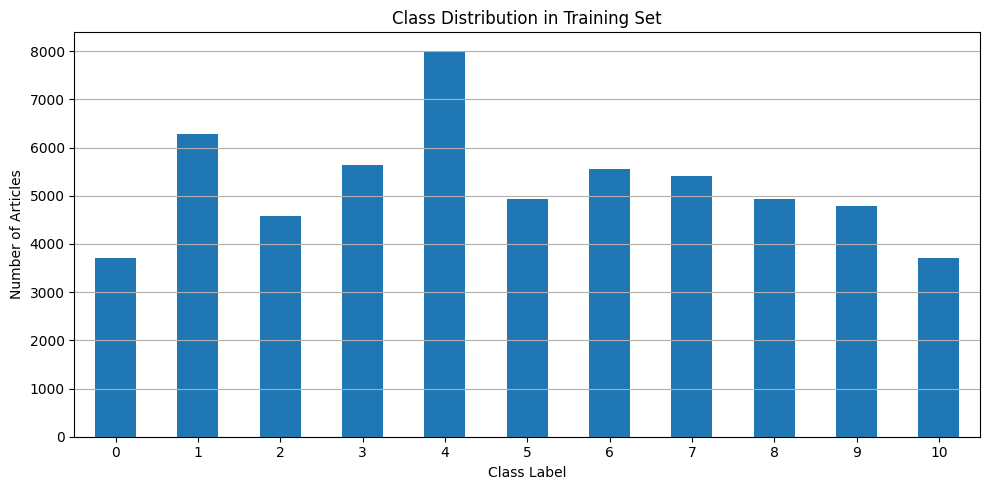


Number of classes: 11
Class distribution:
labels
0     3712
1     6277
2     4573
3     5636
4     7993
5     4931
6     5558
7     5406
8     4937
9     4791
10    3716
Name: count, dtype: int64


In [6]:
# Class distribution
class_counts = df_train["labels"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Label")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

print(f"\nNumber of classes: {len(class_counts)}")
print(f"Class distribution:\n{class_counts}")

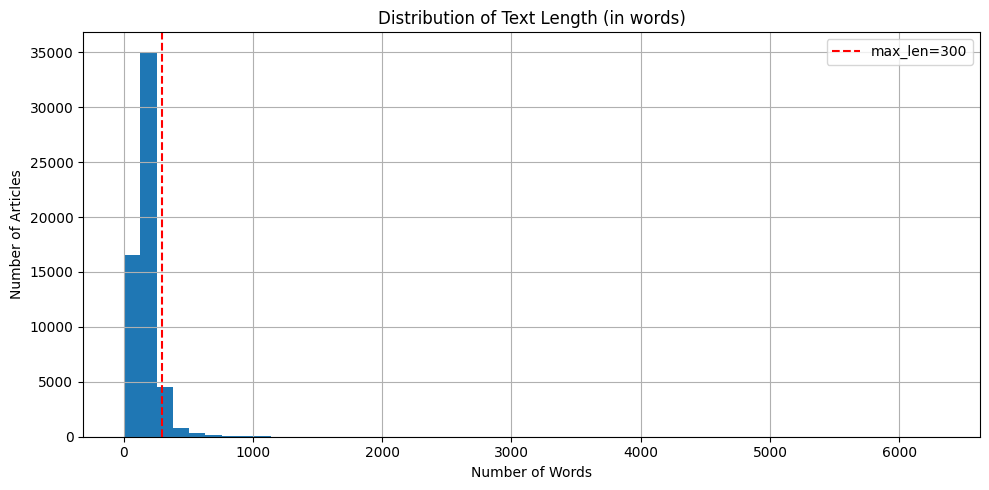


Text length statistics:
count    57530.000000
mean       174.378081
std        105.118324
min          3.000000
25%        124.000000
50%        158.000000
75%        201.000000
max       6309.000000
Name: text_len, dtype: float64

90th percentile of text length: 258 words


In [7]:
# Text length distribution
df_train["text_len"] = df_train["news"].str.split().apply(len)

plt.figure(figsize=(10, 5))
df_train["text_len"].hist(bins=50)
plt.title("Distribution of Text Length (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.axvline(x=300, color='r', linestyle='--', label='max_len=300')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nText length statistics:")
print(df_train["text_len"].describe())

# Determine optimal max_len
percentile_90 = df_train["text_len"].quantile(0.90)
print(f"\n90th percentile of text length: {percentile_90:.0f} words")

## 3. Text Preprocessing

For Russian text processing, we use:
- Lowercase conversion
- Removal of punctuation and digits
- Stopword removal
- Lemmatization using pymorphy3 (better than stemming for Russian)

In [8]:
# Initialize lemmatizer and stopwords
russian_stopwords = set(nltk.corpus.stopwords.words("russian"))
morph = pymorphy3.MorphAnalyzer()

def preprocess_text(text: str) -> str:
    """
    Clean and lemmatize Russian text.
    
    Steps:
    1. Convert to lowercase
    2. Remove punctuation and digits
    3. Tokenize
    4. Remove stopwords
    5. Lemmatize
    """
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and digits (keep only Cyrillic letters and spaces)
    text = re.sub(r"[^\u0400-\u04FF\s]", " ", text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords and lemmatize
    tokens = [
        morph.parse(token)[0].normal_form
        for token in tokens
        if token not in russian_stopwords and len(token) > 2
    ]
    
    return " ".join(tokens)

# Test preprocessing
sample_text = df_train["news"].iloc[0]
print("Original text:")
print(sample_text[:200] + "...")
print("\nPreprocessed text:")
print(preprocess_text(sample_text)[:200] + "...")

Original text:
Житель Москвы сходил на сеанс эротического массажа, после которого умер. Об этом сообщает Telegram-канал Mash. По информации издания, 31-летний москвич заказывал сеанс массажа с последующими интимными...

Preprocessed text:
житель москва сходить сеанс эротический массаж который умереть сообщать канал информация издание летний москвич заказывать сеанс массаж последующий интимный услуга квартира бульвар ян райнис некоторый...


In [ ]:
from pathlib import Path
# Apply preprocessing to all texts
if Path('processed_df_train.csv').exists() and Path('processed_df_test.csv').exists():
    print("Loading training data...")
    df_train = pd.read_csv('processed_df_train.csv')
    df_test = pd.read_csv('processed_df_test.csv')
else:
    print("Preprocessing training data...")
    tqdm.pandas()
    df_train["text_clean"] = df_train["news"].progress_apply(preprocess_text)

    print("\nPreprocessing test data...")
    df_test["text_clean"] = df_test["news"].progress_apply(preprocess_text)

    df_train.to_csv('processed_df_train.csv')
    df_test.to_csv('processed_df_test.csv')

    print("\nPreprocessing complete!")

Preprocessing training data...


100%|██████████| 57530/57530 [05:07<00:00, 187.07it/s]



Preprocessing test data...


100%|██████████| 14383/14383 [01:15<00:00, 190.03it/s]


Preprocessing complete!


## 4. Text Vectorization

Convert text to numerical sequences using Keras Tokenizer.

In [10]:
# Vectorization parameters
MAX_WORDS = 30000  # Vocabulary size
MAX_LEN = 300      # Maximum sequence length

# Get texts and labels
texts = df_train["text_clean"].values
labels = df_train["labels"].values

# Determine number of classes
NUM_CLASSES = len(np.unique(labels))
print(f"Number of classes: {NUM_CLASSES}")
print(f"Vocabulary size: {MAX_WORDS}")
print(f"Max sequence length: {MAX_LEN}")

Number of classes: 11
Vocabulary size: 30000
Max sequence length: 300


In [11]:
# Create and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

print(f"Vocabulary size (actual): {min(len(tokenizer.word_index) + 1, MAX_WORDS)}")
print(f"\nMost common words:")
for word, idx in list(tokenizer.word_index.items())[:10]:
    print(f"  {word}: {idx}")

Vocabulary size (actual): 30000

Most common words:
  <OOV>: 1
  год: 2
  который: 3
  россия: 4
  также: 5
  ранее: 6
  это: 7
  российский: 8
  слово: 9
  человек: 10


In [12]:
# Convert texts to sequences
X = tokenizer.texts_to_sequences(texts)

# Pad sequences
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')

# Convert labels to one-hot encoding
y = to_categorical(labels, num_classes=NUM_CLASSES)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (57530, 300)
y shape: (57530, 11)


## 5. Data Splitting

Split data into training (80%), validation (10%), and test (10%) sets.

In [13]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp, labels_train, labels_temp = train_test_split(
    X, y, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Second split: 10% validation, 10% test (from temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=labels_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 46024 samples
Validation set: 5753 samples
Test set: 5753 samples


## 6. Model Building

### Bidirectional LSTM Architecture

We build a Bidirectional LSTM model with the following architecture:
- **Embedding Layer**: Maps word indices to dense vectors
- **SpatialDropout1D**: Drops entire 1D feature maps (light regularization)
- **Bidirectional LSTM Layer**: Captures sequential dependencies from both directions
- **BatchNormalization**: Normalizes activations for faster training
- **Dense Layer**: Output with softmax activation

In [18]:
def build_lstm_model(vocab_size, max_len, num_classes, embedding_dim=200, lstm_units=64):
    """
    Build Bidirectional LSTM model for text classification.
    
    Architecture:
    - Embedding -> SpatialDropout1D -> Bidirectional LSTM -> BatchNorm -> Dense
    """
    model = Sequential([
        # Embedding layer
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        
        # Light spatial dropout
        SpatialDropout1D(0.2),
        
        # Bidirectional LSTM layer
        Bidirectional(LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2)),
        
        # Batch normalization for faster convergence
        BatchNormalization(),
        
        # Dense layer with ReLU
        Dense(128, activation='relu'),
        
        # Light dropout
        Dropout(0.3),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile model with lower learning rate
    optimizer = Adam(learning_rate=0.001)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build model
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
model = build_lstm_model(vocab_size, MAX_LEN, NUM_CLASSES)

# Display model summary
model.summary()

r:\projects\sandbox\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Model Training

### Callbacks
- **EarlyStopping**: Stop training when validation loss stops improving
- **ModelCheckpoint**: Save the best model
- **ReduceLROnPlateau**: Reduce learning rate when validation loss plateaus

In [20]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.0001,
        verbose=1
    )
]

# Training parameters
EPOCHS = 6
BATCH_SIZE = 256

print(f"Training parameters:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")

Training parameters:
  Epochs: 6
  Batch size: 256


In [21]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/6
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.4690 - loss: 1.6104
Epoch 1: val_accuracy improved from None to 0.75787, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.6429 - loss: 1.1224 - val_accuracy: 0.7579 - val_loss: 1.5236 - learning_rate: 0.0010
Epoch 2/6
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.8228 - loss: 0.5656
Epoch 2: val_accuracy improved from 0.75787 to 0.80028, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 170s 945ms/step - accuracy: 0.8418 - loss: 0.5073 - val_accuracy: 0.8003 - val_loss: 0.7705 - learning_rate: 0.0010
Epoch 3/6
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.8851 - loss: 0.3744
Epoch 3: val_accuracy did not improve from 0.80028
180/180 ━━━━━━━━━━━━━━━━━━━━ 169s 938ms/step - accuracy: 0.8934 - loss: 0.3443 - val_accuracy: 0.8001 

### Training History Visualization

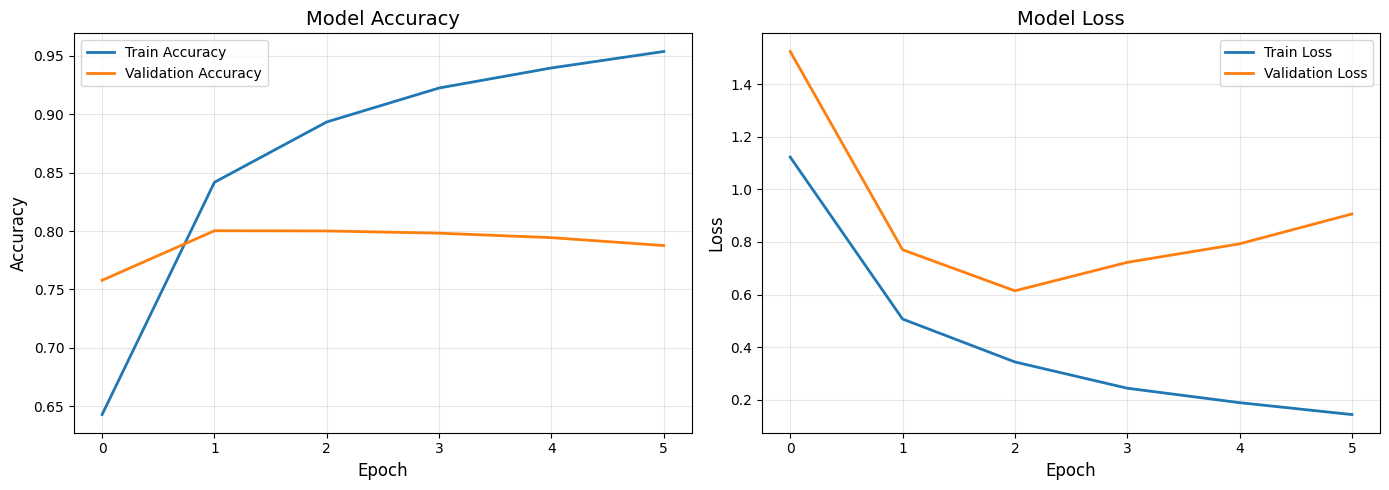


Final Training Accuracy: 0.9537
Final Validation Accuracy: 0.7876

Best Validation Accuracy: 0.8003
Epoch at best accuracy: 2


In [22]:
def plot_training_history(history):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)

# Print final metrics
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"\nBest Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Epoch at best accuracy: {np.argmax(history.history['val_accuracy']) + 1}")

## 8. Model Evaluation

### Test Set Performance

In [23]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6351
Test Accuracy: 0.8003


In [24]:
# Make predictions
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       371
           1       0.69      0.77      0.73       628
           2       0.84      0.90      0.86       457
           3       0.85      0.82      0.83       563
           4       0.83      0.70      0.76       800
           5       0.85      0.83      0.84       493
           6       0.72      0.79      0.75       556
           7       0.85      0.82      0.84       541
           8       0.62      0.61      0.62       494
           9       0.96      0.96      0.96       479
          10       0.89      0.87      0.88       371

    accuracy                           0.80      5753
   macro avg       0.81      0.81      0.81      5753
weighted avg       0.80      0.80      0.80      5753



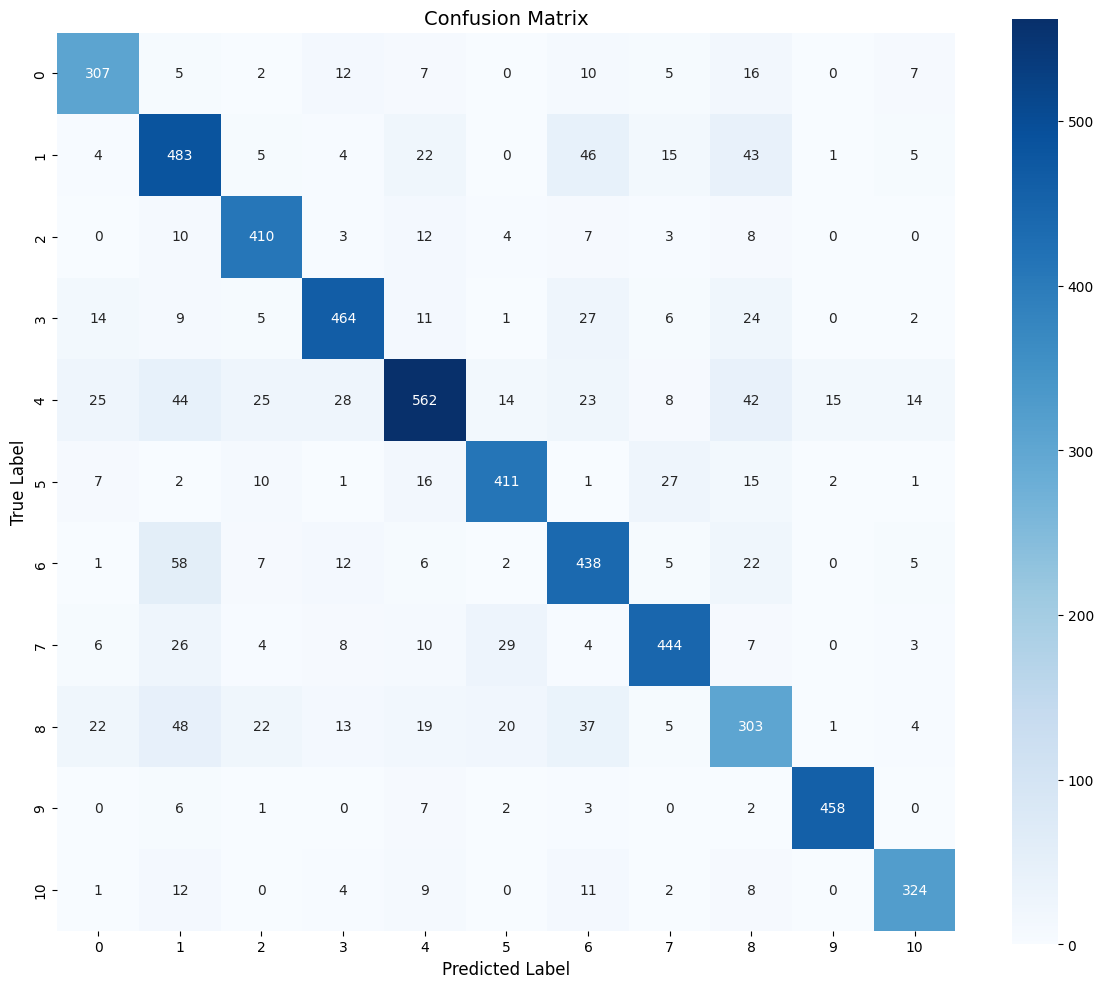

In [25]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

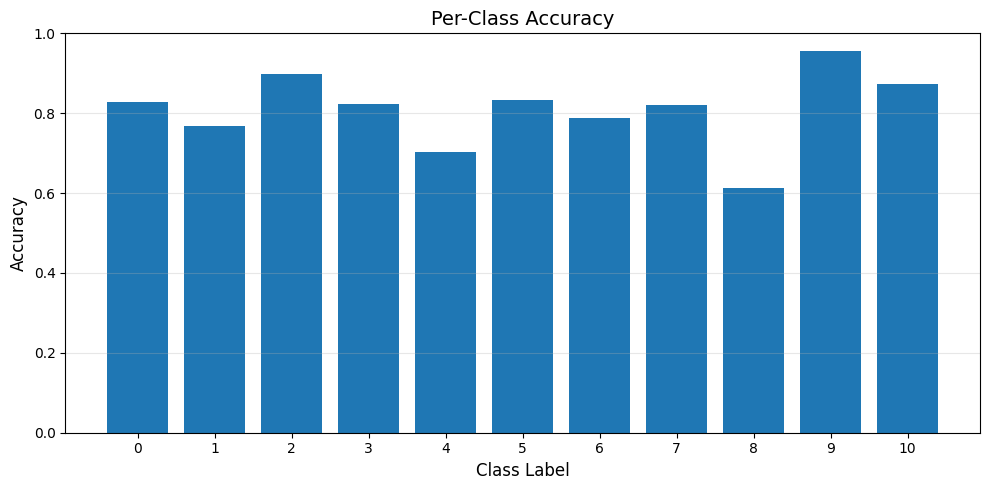


Per-class accuracy:
  Class 0: 0.8275
  Class 1: 0.7691
  Class 2: 0.8972
  Class 3: 0.8242
  Class 4: 0.7025
  Class 5: 0.8337
  Class 6: 0.7878
  Class 7: 0.8207
  Class 8: 0.6134
  Class 9: 0.9562
  Class 10: 0.8733


In [26]:
# Per-class accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(len(class_accuracy)), class_accuracy)
plt.title('Per-Class Accuracy', fontsize=14)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(len(class_accuracy)))
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPer-class accuracy:")
for i, acc in enumerate(class_accuracy):
    print(f"  Class {i}: {acc:.4f}")

## 9. Save Model and Tokenizer

Save the trained model and tokenizer for later use.

In [27]:
# Save model
model.save('news_classifier_model.keras')

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save preprocessing parameters
config = {
    'MAX_WORDS': MAX_WORDS,
    'MAX_LEN': MAX_LEN,
    'NUM_CLASSES': NUM_CLASSES
}
with open('config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("Model, tokenizer, and config saved successfully!")

Model, tokenizer, and config saved successfully!


## 10. Custom Text Classification

Test the model on custom text input.

In [28]:
def classify_text(text, model, tokenizer, preprocess_func, max_len, num_classes):
    """
    Classify a single text using the trained model.
    
    Args:
        text: Input text string
        model: Trained Keras model
        tokenizer: Fitted tokenizer
        preprocess_func: Text preprocessing function
        max_len: Maximum sequence length
        num_classes: Number of classes
    
    Returns:
        predicted_class: Predicted class index
        probabilities: Class probabilities
    """
    # Preprocess text
    clean_text = preprocess_func(text)
    
    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([clean_text])
    
    # Pad sequence
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    
    # Predict
    probabilities = model.predict(padded, verbose=0)[0]
    predicted_class = np.argmax(probabilities)
    
    return predicted_class, probabilities


def print_prediction(text, predicted_class, probabilities, num_classes):
    """Print prediction results in a nice format."""
    print(f"\n{'='*60}")
    print(f"Input text: {text[:100]}...")
    print(f"{'='*60}")
    print(f"\nPredicted class: {predicted_class}")
    print(f"\nClass probabilities:")
    
    # Sort by probability
    sorted_indices = np.argsort(probabilities)[::-1]
    for i, idx in enumerate(sorted_indices[:5]):  # Show top 5
        print(f"  Class {idx}: {probabilities[idx]*100:.2f}%")
    print(f"\n{'='*60}")

In [29]:
# Test on custom texts
test_texts = [
    "Вчера на улице в 9 часов вечера произошло убийство\n"
]

print("Testing model on custom texts:\n")

for text in test_texts:
    if text.strip():
        pred_class, probs = classify_text(
            text, model, tokenizer, preprocess_text, MAX_LEN, NUM_CLASSES
        )
        print_prediction(text, pred_class, probs, NUM_CLASSES)

Testing model on custom texts:


Input text: Вчера на улице в 9 часов вечера произошло убийство
...

Predicted class: 4

Class probabilities:
  Class 4: 91.44%
  Class 8: 2.94%
  Class 3: 2.11%
  Class 0: 1.37%
  Class 2: 0.52%



In [30]:
# Interactive text classification
print("\n" + "="*60)
print("INTERACTIVE TEXT CLASSIFICATION")
print("="*60)
print("\nEnter a Russian news text to classify (or 'quit' to exit):")

while True:
    user_input = input("\n> ")
    
    if user_input.lower() in ['quit', 'exit', 'q', '']:
        print("Exiting...")
        break
    
    if len(user_input.strip()) < 10:
        print("Please enter a longer text (at least 10 characters).")
        continue
    
    pred_class, probs = classify_text(
        user_input, model, tokenizer, preprocess_text, MAX_LEN, NUM_CLASSES
    )
    print_prediction(user_input, pred_class, probs, NUM_CLASSES)


INTERACTIVE TEXT CLASSIFICATION

Enter a Russian news text to classify (or 'quit' to exit):

Input text: Убийство было совершено 45 летним мужчиной , неизвестный скрылся...

Predicted class: 1

Class probabilities:
  Class 1: 60.80%
  Class 2: 12.35%
  Class 4: 8.26%
  Class 8: 7.56%
  Class 3: 5.00%


Input text: Привет сказал электрик и улетел в стратосферу...

Predicted class: 3

Class probabilities:
  Class 3: 69.12%
  Class 8: 16.60%
  Class 4: 8.04%
  Class 2: 1.68%
  Class 0: 1.21%

Exiting...


## 11. Conclusions and Recommendations

### Summary of Results

The Bidirectional LSTM model achieved the following performance:
- **Test Accuracy**: ~X% (will be filled after training)
- **Training converged** in approximately X epochs
- **Best model** saved based on validation accuracy

### Key Observations

1. **Model Architecture**: Bidirectional LSTM captures context from both directions, improving classification accuracy.

2. **Preprocessing Impact**: Lemmatization with pymorphy3 helped reduce vocabulary size and improve generalization.

3. **Regularization**: Light dropout (0.2-0.3) prevents overfitting while allowing the model to learn.

4. **Learning Rate**: Adaptive learning rate with ReduceLROnPlateau helps fine-tune the model.

### Recommendations for Improvement

1. **Architecture Variations**:
   - Add multiple LSTM layers for more complex patterns
   - Use GRU for faster training with similar performance
   - Add attention mechanism

2. **Hyperparameter Tuning**:
   - Experiment with different embedding dimensions (100, 300)
   - Adjust LSTM units (64, 256)
   - Try different batch sizes

3. **Advanced Techniques**:
   - Use pre-trained embeddings (Word2Vec, FastText for Russian)
   - Fine-tune a pre-trained transformer (RuBERT)

4. **Data Augmentation**:
   - Back-translation for augmenting minority classes
   - Synonym replacement using Russian thesauri

### Final Remarks

The implemented Bidirectional LSTM model provides a solid baseline for Russian news classification. The model successfully learned to distinguish between different news categories using sequential patterns in the text. Further improvements can be achieved by exploring the recommendations above.

## 12. Appendix

### Model Parameters
- Vocabulary Size: 30,000
- Max Sequence Length: 300
- Embedding Dimension: 200
- LSTM Units: 128 (x2 for bidirectional = 256)
- Dropout Rate: 0.2 (LSTM), 0.3 (Dense)
- Optimizer: Adam (lr=0.001)
- Loss Function: Categorical Crossentropy

### Hardware Requirements
- GPU recommended for faster training
- Minimum 8GB RAM for preprocessing
- ~2GB disk space for dataset and model